# Scenario Comparison Analysis

In [3]:
import json
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

In [5]:
home = "/home/lucakristin/Desktop/my_pypsa"
base_folder = "germany_base_"
cluster = "450" 

### Create scenario network 

In [44]:
wind_conditions = ["windy", "notwindy", "windvariability"]
capacity_scenarios = ["germany_scenario1", "germany_scenario2"]

!python ../create_germany_scenario.py \
    --home {home} \
    --base-folder {base_folder} \
    --cluster {cluster} \
    --wind-condition {" ".join(wind_conditions)} \
    --capacity-scenario {" ".join(capacity_scenarios)}

[Tue May  5 16:00:08 2026] Processing scenario: germany_scenario1 with wind condition: windy
[Tue May  5 16:00:08 2026] Loading base network from: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/results/germany_base_windy/networks/base_s_450_elec_.nc
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
[Tue May  5 16:00:10 2026] Loading scenario configuration from: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/config/scenario_configs/germany_scenario1.json
[Tue May  5 16:00:10 2026] Modifying generator capacities for scenario 'germany_scenario1'.
Removing capacity from zero-share carriers ['coal', 'lignite', 'OCGT', 'oil', 'offwind-dc']: 51606.07 MW
Current total capacity of selected carriers: 175224.75 MW
Scale capacity of selected carriers by 1.000 to 175224.75 MW
solar: modified from 48771.25 MW to 44244.21 MW
onwind: modified 

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


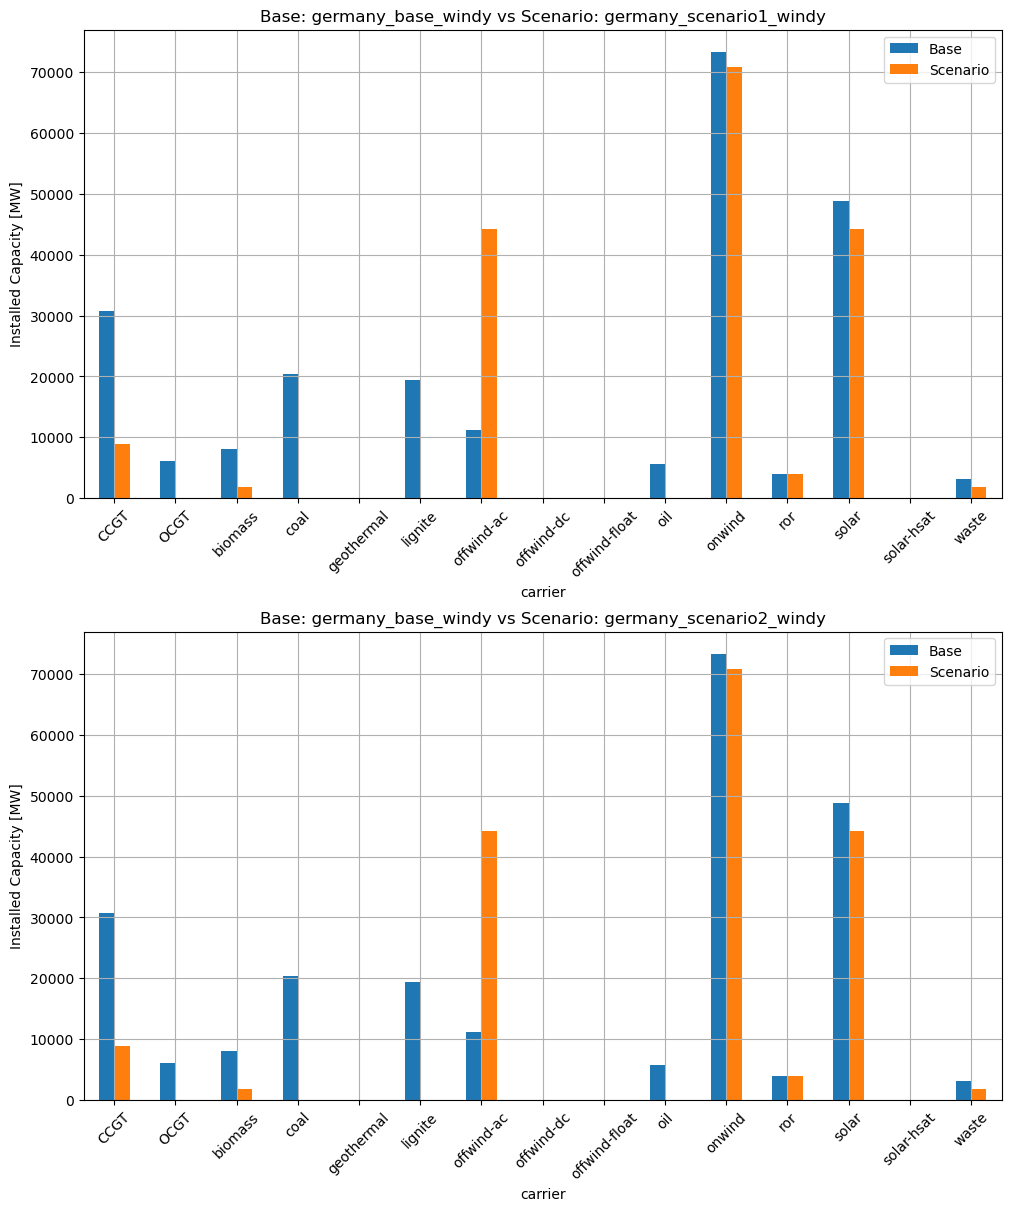

In [51]:
def load_networks(home, base_folder, cluster, wind_opt, scenario_name):
    """Loads the base and scenario networks."""
    base_config_name = f"{base_folder}{wind_opt}"
    scenario_config_name = f"{scenario_name}_{wind_opt}"
    
    base_network_path_unsolved = f"{home}/pypsa-eur/results/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
    n_base_unsolved = pypsa.Network(base_network_path_unsolved)
    
    scenario_network_path_unsolved = f"{home}/pypsa-eur/resources/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
    n_scenario_unsolved = pypsa.Network(scenario_network_path_unsolved)
    
    return n_base_unsolved, n_scenario_unsolved, base_config_name, scenario_config_name

def plot_capacity_comparison(ax, n_base, n_scenario, base_name, scenario_name):
    """Plots the initial installed capacity comparison on a given axes."""
    p_nom_base = n_base.generators.groupby("carrier").p_nom.sum()
    p_nom_scenario = n_scenario.generators.groupby("carrier").p_nom.sum()

    df = pd.DataFrame({
        "Base": p_nom_base,
        "Scenario": p_nom_scenario
    }).dropna()

    df.plot(kind="bar", ax=ax, rot=45)
    ax.set_ylabel("Installed Capacity [MW]")
    ax.set_title(f"Base: {base_name} vs Scenario: {scenario_name}")
    ax.grid(True)

# Create a figure with subplots
num_scenarios = len(capacity_scenarios)
fig, axes = plt.subplots(num_scenarios, 1, figsize=(10, 6 * num_scenarios), constrained_layout=True)

wind_opt = "windy"  # or "not-windy" or "wind-variability"
for j, scenario_name in enumerate(capacity_scenarios):
    ax = axes[j]
    n_base, n_scenario, base_name, scenario_name_full = load_networks(home, base_folder, cluster, wind_opt, scenario_name)
    plot_capacity_comparison(ax, n_base, n_scenario, base_name, scenario_name_full)

plt.show()

---
# Solving networks

## 1. Check if config.yaml exists before solving 

In [200]:
# Check that a matching scenario config file exists before creating the network.
scenario_yaml_path = f"{home}/pypsa-eur/config/config.{scenario_config_name}.yaml"
if not os.path.isfile(scenario_yaml_path):
    raise FileNotFoundError(
        f"Missing scenario config file: {scenario_yaml_path}\n"
        f"Expected a file named config.{scenario_config_name}.yaml in pypsa-eur/config/."
    )
print(f"Found scenario config: {scenario_yaml_path}")

Found scenario config: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/config/config.germany_scenario_1.yaml


## 2. Solve the network -> for line loads
```bash
snakemake -n -call solve_elec_networks --configfile config/config.germany_scenario.yaml
```

#### Unlock command

```bash
cd pypsa-eur && conda activate pypsa-eur && snakemake -call solve_elec_networks --configfile config/config.germany_scenario_1.yaml --unlock
```

```
Using workflow specific profile profiles/default for setting default command line arguments.
Config file config/config.default.yaml is extended by additional config specified via the command line.
Config file config/plotting.default.yaml is extended by additional config specified via the command line.
Unlocked working directory.
```

## 3. Load solved networks

In [226]:
# --- Load Base Network ---
base_network_path = f"{home}/pypsa-eur/results/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
n_base = pypsa.Network(base_network_path, name="Base Network")
n_base.name = "Base Network"

# --- Load Scenario Network ---
scenario_network_path = f"{home}/pypsa-eur/results/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
n_scenario = pypsa.Network(scenario_network_path, name="Scenario Network")
n_scenario.name = "Scenario Network"

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
